In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import shutil
from tqdm.auto import tqdm
import itertools

In [2]:
df = pd.read_csv('merged_disease_weather_data.csv')

df.columns = [
    'Year', 'Month', 'Malaria_Sample', 'Malaria_vivax',
    'Malaria_falciparum', 'Malaria_inpatient',
    'Dengue_inpatient', 'Typhoid_inpatient', 'COPD_Asthma_inpatient',
    'TB_inpatient', 'DD_inpatient', 'Hepatitis_inpatient',
    'specific_humidity', 'relative_humidity', 'temperature', 't2m_max', 't2m_min', 'temp', 'District'
    ]

# delete 'temperature' column
df.drop(columns=['temperature'], inplace=True)

# save the cleaned data
df.to_csv('cleaned_disease_weather_data.csv', index=False)



In [3]:
df = pd.read_csv('cleaned_disease_weather_data.csv')
df

,Year,Month,Malaria_Sample,Malaria_vivax,Malaria_falciparum,Malaria_inpatient,Dengue_inpatient,Typhoid_inpatient,COPD_Asthma_inpatient,TB_inpatient,DD_inpatient,Hepatitis_inpatient,specific_humidity,relative_humidity,t2m_max,t2m_min,temp,District
0,2019,January,206,0,0,0,0,3,40,0,19,0,3.128710,56.571613,9.310645,-2.638387,2.498387,Bageshwar
1,2019,February,297,0,0,0,0,1,56,0,6,0,4.086786,66.315000,9.717143,-2.168214,3.446786,Bageshwar
2,2019,March,233,0,0,-1,-1,2,34,2,9,-1,4.672258,59.078710,14.191935,0.214839,7.243226,Bageshwar
3,2019,April,172,0,0,0,0,3,29,1,36,0,6.476667,52.977000,21.330000,7.779000,14.260000,Bageshwar
4,2019,May,337,0,0,0,0,2,41,2,28,3,6.067097,40.951613,24.924516,10.151290,17.555806,Bageshwar
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1555,2010,August,81,-1,-1,-1,-1,-1,-1,-1,-1,-1,17.067742,90.570000,24.087419,19.228065,21.420000,Pithoragarh
1556,2010,September,69,-1,-1,-1,-1,-1,-1,-1,-1,-1,15.185667,88.001667,23.223333,17.429333,20.014667,Pithoragarh
1557,2010,October,89,-1,-1,-1,-1,-1,-1,-1,-1,-1,11.131935,75.149677,22.518710,13.787742,17.558710,Pithoragarh
1558,2010,November,68,-1,-1,-1,-1,-1,-1,-1,-1,-1,7.728000,65.174667,20.089667,10.410000,14.271000,Pithoragarh


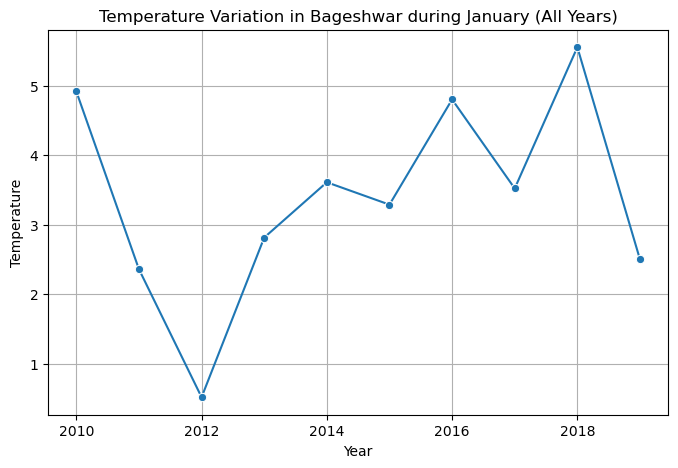

In [4]:
# Example: Plot temperature variation for 'Bageshwar' in 'January' over all years

district = 'Bageshwar'
month = 'January'

subset = df[(df['District'] == district) & (df['Month'] == month)]
plt.figure(figsize=(8, 5))
sns.lineplot(data=subset, x='Year', y='temp', marker='o')
plt.title(f'Temperature Variation in {district} during {month} (All Years)')
plt.ylabel('Temperature')
plt.xlabel('Year')
plt.grid(True)
plt.show()

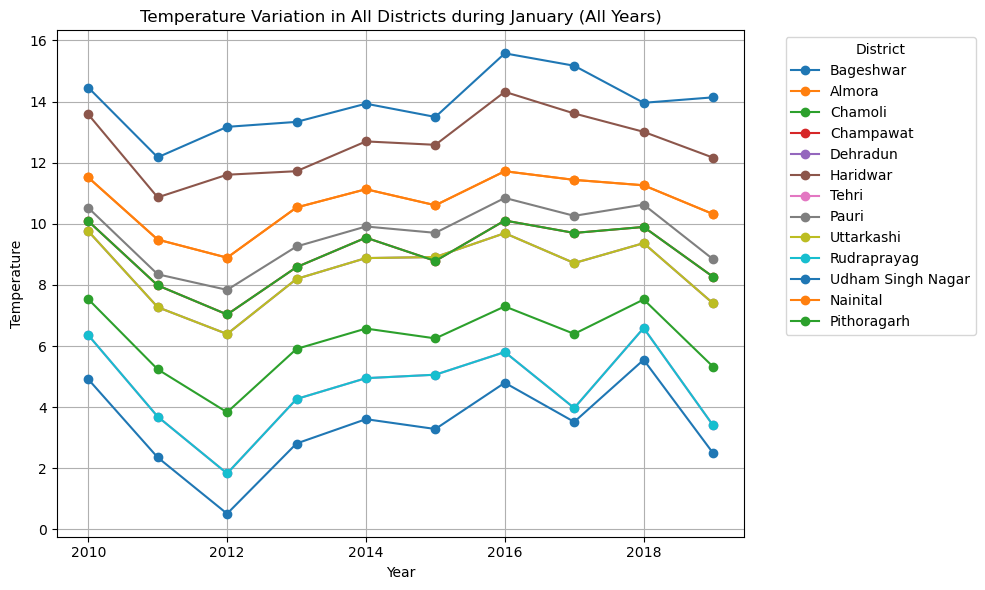

In [5]:
# Plot temperature variation for 'January' over all years for each district

month = 'January'
districts = df['District'].unique()

# Create directory for figures if it doesn't exist
figures_dir = 'figures'
os.makedirs(figures_dir, exist_ok=True)

plt.figure(figsize=(10, 6))
for district in districts:
    subset = df[(df['District'] == district) & (df['Month'] == month)]
    plt.plot(subset['Year'], subset['temp'], marker='o', label=district)

plt.title(f'Temperature Variation in All Districts during {month} (All Years)')
plt.ylabel('Temperature')
plt.xlabel('Year')
plt.legend(title='District', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

# Save the figure
plt.savefig(os.path.join(figures_dir, f'temperature_variation_{month}_all_districts.png'))

plt.show()

In [6]:
# Remove previous figures directory and all its contents if it exists
figures_dir = 'figures'
if os.path.exists(figures_dir):
    shutil.rmtree(figures_dir)

weather_params = ['temp', 't2m_max', 't2m_min', 'specific_humidity', 'relative_humidity']
months = df['Month'].unique()
month_map = {
    'January': '01', 'February': '02', 'March': '03', 'April': '04',
    'May': '05', 'June': '06', 'July': '07', 'August': '08',
    'September': '09', 'October': '10', 'November': '11', 'December': '12'
}
districts = df['District'].unique()

# Altitude mapping for each district (in meters)
district_altitude = {
    'Bageshwar': 1004,
    'Almora': 1638,
    'Chamoli': 1300,
    'Champawat': 1615,
    'Dehradun': 640,
    'Haridwar': 314,
    'Tehri': 1750,
    'Pauri': 1814,
    'Uttarkashi': 1158,
    'Rudraprayag': 895,
    'Udham Singh Nagar': 230,
    'Nainital': 2084,
    'Pithoragarh': 1627
}

palette = sns.color_palette("tab20", n_colors=len(districts))
linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 1)), (0, (1, 1)), (0, (3, 5, 1, 5)), (0, (5, 10)), (0, (1, 10)), (0, (3, 10, 1, 10)), (0, (5, 2)), (0, (1, 2))]

total = len(weather_params) * len(months)
with tqdm(total=total, desc="Generating plots", ncols=100, bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]') as pbar:
    for param in weather_params:
        param_dir = os.path.join(figures_dir, param)
        os.makedirs(param_dir, exist_ok=True)
        for month in months:
            plt.figure(figsize=(10, 6))
            color_cycle = itertools.cycle(palette)
            linestyle_cycle = itertools.cycle(linestyles)
            for idx, district in enumerate(districts):
                subset = df[(df['District'] == district) & (df['Month'] == month)]
                altitude = district_altitude.get(district, "NA")
                label = f"{district} ({altitude}m)"
                plt.plot(
                    subset['Year'],
                    subset[param],
                    marker='o',
                    label=label,
                    color=next(color_cycle),
                    linestyle=next(linestyle_cycle)
                )
            plt.title(f'{param.replace("_", " ").title()} Variation in All Districts during {month} (All Years)')
            plt.ylabel(param.replace("_", " ").title())
            plt.xlabel('Year')
            plt.legend(title='District (Altitude)', bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True)
            plt.tight_layout()
            month_num = month_map.get(month, month)
            filename = f'{param}_variation_{month_num}_all_districts.png'
            plt.savefig(os.path.join(param_dir, filename))
            plt.close()
            pbar.update(1)

Generating plots:   0%|                                                             | 0/60 [00:00<?]

In [8]:
# Plot and save figures for all disease parameters for all months over all years for each district
disease_params = [
    'Malaria_Sample', 'Malaria_vivax', 'Malaria_falciparum', 'Malaria_inpatient',
    'Dengue_inpatient', 'Typhoid_inpatient', 'COPD_Asthma_inpatient',
    'TB_inpatient', 'DD_inpatient', 'Hepatitis_inpatient'
]
disease_figures_dir = 'disease_figures'
if os.path.exists(disease_figures_dir):
    shutil.rmtree(disease_figures_dir)
    
# replace nan values with 0
df_ = df.fillna(0)

total_disease = len(disease_params) * len(months)
for param in tqdm(disease_params):
    param_dir = os.path.join(disease_figures_dir, param)
    os.makedirs(param_dir, exist_ok=True)
    for month in months:
        plt.figure(figsize=(10, 6))
        color_cycle = itertools.cycle(palette)
        linestyle_cycle = itertools.cycle(linestyles)
        for idx, district in enumerate(districts):
            subset = df_[(df_['District'] == district) & (df_['Month'] == month)]
            altitude = district_altitude.get(district, "NA")
            label = f"{district} ({altitude}m)"
            plt.plot(
                subset['Year'],
                subset[param],
                marker='o',
                label=label,
                color=next(color_cycle),
                linestyle=next(linestyle_cycle)
            )
        plt.title(f'{param.replace("_", " ").title()} Variation in All Districts during {month} (All Years)')
        plt.ylabel(param.replace("_", " ").title())
        plt.xlabel('Year')
        plt.yscale('log')
        plt.legend(title='District (Altitude)', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True)
        plt.tight_layout()
        month_num = month_map.get(month, month)
        filename = f'{param}_variation_{month_num}_all_districts.png'
        plt.savefig(os.path.join(param_dir, filename))
        # plt.show()
        plt.close()

  0%|          | 0/10 [00:00<?, ?it/s]